# 14 — Comparaison Méthodologie v1 vs v2

Ce notebook compare systématiquement :
- **v1** : Pipeline ExtraTrees final actuel (notebook 09)
- **v2** : Pipeline amélioré avec :
  - `froude_proxy` = sqrt(E/g) — loi de Holsapple
  - `sqrt_horizontal_E_over_g` — portée balistique
  - `log_E_over_g` — version log pour linéariser
  - `porosity_regime_soft` — transition douce sigmoid
  - `strength_regime_soft` — transition douce sigmoid
  - Log1p transform sur R95 et fines_frac
  - NGBoost pour R95 (distribution probabiliste)
  - Correction du biais R95 near-zone

**Métriques comparées** : MAE, RMSE, R2, normalized_MAE, P95_AE, Bias, feasible F1, near-zone R95 MAE

**Verdict final** : quelle soumission envoyer le 5 mai

## 1. Imports

In [1]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.neighbors import NearestNeighbors

try:
    from ngboost import NGBRegressor
    from ngboost.distns import Normal
    NGBOOST_AVAILABLE = True
    print('NGBoost disponible ✓')
except ImportError:
    NGBOOST_AVAILABLE = False
    print('NGBoost non disponible — pip install ngboost')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)

PROJECT_ROOT    = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FORWARD_DIR     = PROJECT_ROOT / 'data' / 'raw' / 'forward_prediction'
INVERSE_DIR     = PROJECT_ROOT / 'data' / 'raw' / 'inverse_design'
OUTPUTS_DIR     = PROJECT_ROOT / 'outputs'
SUBMISSIONS_DIR = OUTPUTS_DIR / 'submissions'
MODELS_DIR      = OUTPUTS_DIR / 'models'
REPORTS_DIR     = PROJECT_ROOT / 'reports'
FIGURES_DIR     = OUTPUTS_DIR / 'figures'

for p in [SUBMISSIONS_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Submissions :', SUBMISSIONS_DIR)

NGBoost disponible ✓
Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Submissions : /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions


## 2. Chargement des données

In [2]:
input_cols = [
    'energy', 'angle_rad', 'coupling', 'strength',
    'porosity', 'gravity', 'atmosphere', 'shape_factor',
]
target_cols          = ['P80', 'fines_frac', 'oversize_frac', 'R95', 'R50_fines', 'R50_oversize']
fragmentation_targets = ['P80', 'fines_frac', 'oversize_frac']
distance_targets      = ['R95', 'R50_fines', 'R50_oversize']

raw_train = pd.read_csv(FORWARD_DIR / 'train.csv')[input_cols]
raw_test  = pd.read_csv(FORWARD_DIR / 'test.csv')[input_cols]
y         = pd.read_csv(FORWARD_DIR / 'train_labels.csv')[target_cols]

constraints_path = INVERSE_DIR / 'constraints.json'
if constraints_path.exists():
    with open(constraints_path) as f:
        constraints_data = json.load(f)
    output_constraints = constraints_data['constraints']
else:
    output_constraints = {'p80_min': 96.0, 'p80_max': 101.0, 'r95_max': 175.0}

p80_min = output_constraints['p80_min']
p80_max = output_constraints['p80_max']
r95_max = output_constraints['r95_max']

print(f'Train : {raw_train.shape} | Test : {raw_test.shape} | Labels : {y.shape}')
print(f'Contraintes : P80 ∈ [{p80_min}, {p80_max}], R95 ≤ {r95_max}')

# Vérification OOD : gravity=1.02 dans le test
print(f'\nGravity train : {sorted(raw_train.gravity.unique())}')
print(f'Gravity test  : {sorted(raw_test.gravity.unique())}')
test_new_gravity = raw_test[~raw_test.gravity.isin(raw_train.gravity.unique())]
print(f'Points test avec gravity INCONNUE : {len(test_new_gravity)} / {len(raw_test)}')

Train : (2930, 8) | Test : (492, 8) | Labels : (2930, 6)
Contraintes : P80 ∈ [96.0, 101.0], R95 ≤ 175.0

Gravity train : [np.float64(1.62), np.float64(3.71), np.float64(9.81)]
Gravity test  : [np.float64(1.02), np.float64(1.38), np.float64(4.91), np.float64(7.03), np.float64(10.47)]
Points test avec gravity INCONNUE : 492 / 492


## 3. Feature Engineering — v1 (baseline actuelle)

In [3]:
def add_physics_features_v1(X: pd.DataFrame) -> pd.DataFrame:
    """Pipeline feature engineering actuel (notebook 09)."""
    X = pd.DataFrame(X).copy()
    X = X[input_cols].copy()
    eps = 1e-9

    X['effective_energy']              = X['energy'] * X['coupling']
    X['log_energy']                    = np.log1p(X['energy'])
    X['log_effective_energy']          = np.log1p(X['effective_energy'])
    X['sin_angle']                     = np.sin(X['angle_rad'])
    X['cos_angle']                     = np.cos(X['angle_rad'])
    X['tan_angle']                     = np.tan(X['angle_rad'])
    X['horizontal_energy']             = X['effective_energy'] * X['cos_angle']
    X['vertical_energy']               = X['effective_energy'] * X['sin_angle']
    X['vertical_horizontal_ratio']     = X['vertical_energy'] / (X['horizontal_energy'] + eps)
    X['energy_per_strength']           = X['energy'] / (X['strength'] + eps)
    X['effective_energy_per_strength'] = X['effective_energy'] / (X['strength'] + eps)
    X['material_resistance_index']     = X['strength'] * (1 - X['porosity'])
    X['fragmentation_index']           = X['effective_energy'] * X['porosity'] / (X['strength'] + eps)
    X['coupling_porosity']             = X['coupling'] * X['porosity']
    X['coupling_atmosphere']           = X['coupling'] * X['atmosphere']
    X['porosity_strength']             = X['porosity'] * X['strength']
    X['energy_per_gravity']            = X['energy'] / (X['gravity'] + eps)
    X['effective_energy_per_gravity']  = X['effective_energy'] / (X['gravity'] + eps)
    X['horizontal_energy_per_gravity'] = X['horizontal_energy'] / (X['gravity'] + eps)
    X['vertical_energy_per_gravity']   = X['vertical_energy'] / (X['gravity'] + eps)
    X['drag_proxy']                    = X['atmosphere'] * X['shape_factor']
    X['drag_per_gravity']              = X['drag_proxy'] / (X['gravity'] + eps)
    X['atmosphere_shape_energy']       = X['atmosphere'] * X['shape_factor'] * X['effective_energy']
    X['atmosphere_per_gravity']        = X['atmosphere'] / (X['gravity'] + eps)
    X['pi_gravity_proxy']              = (X['gravity'] * X['coupling']) / (X['energy'] + eps)
    X['pi_strength_proxy']             = X['strength'] / (X['gravity'] * X['coupling'] + eps)
    X['pi_atmosphere_proxy']           = X['atmosphere'] / (X['gravity'] * X['coupling'] + eps)
    X['porosity_regime']               = (X['porosity'] > 0.15).astype(int)
    X['strength_regime']               = (X['strength'] > 2.6).astype(int)
    X['angle_regime']                  = (X['angle_rad'] > 0.95).astype(int)
    X['atm_regime']                    = (X['atmosphere'] > 0.30).astype(int)
    X['regime_combo']                  = (X['porosity_regime'] * 8 + X['strength_regime'] * 4
                                         + X['angle_regime'] * 2 + X['atm_regime'])
    X['scaled_energy']                 = X['effective_energy'] / (X['strength'] * np.sqrt(X['gravity']) + eps)
    X['fragility']                     = X['porosity'] / (X['strength'] + eps)
    X['range_proxy']                   = (X['effective_energy'] * X['cos_angle']**2) / (X['gravity'] * X['strength'] + eps)
    X['energy_sin_angle']              = X['energy'] * X['sin_angle']
    X['momentum_proxy']                = X['effective_energy'] * X['sin_angle']
    X['coupling_per_atm_clipped']      = X['coupling'] / (X['atmosphere'] + 1e-3)
    X['log_coupling_per_atm']          = np.log1p(X['coupling_per_atm_clipped'])
    X['retention_factor']              = X['atmosphere'] * X['drag_proxy'] / (X['energy'] + eps)
    X['stress_ratio_compact']          = X['effective_energy'] / (X['material_resistance_index'] + eps)
    X['sqrt_effective_energy_per_strength'] = np.sqrt(X['effective_energy_per_strength'].clip(lower=0))
    X['sqrt_effective_energy_per_gravity']  = np.sqrt(X['effective_energy_per_gravity'].clip(lower=0))
    return X

print('v1 features :', add_physics_features_v1(raw_train).shape[1])

v1 features : 51


## 4. Feature Engineering — v2 (méthodologie améliorée)

In [4]:
def add_physics_features_v2(X: pd.DataFrame) -> pd.DataFrame:
    """
    v2 = v1 + nouvelles features critiques :
    - froude_proxy         : sqrt(E/g) — loi de Holsapple, extrapole sur gravity=1.02
    - sqrt_horizontal_E_g  : portée balistique horizontale
    - log_E_over_g         : version log pour linéariser la relation
    - inv_gravity          : 1/g direct
    - porosity_regime_soft : transition douce (test dans le gap 0.08-0.25)
    - strength_regime_soft : transition douce
    - atm_gravity_comp     : compétition atmosphère vs gravité
    - confinement_index    : énergie retenue vs dispersée
    """
    X = add_physics_features_v1(X)
    eps = 1e-9

    # ── NOUVELLES FEATURES GRAVITATIONNELLES (PRIORITÉ 1) ──────────────────
    # Loi de Holsapple : portée ~ sqrt(E/g)
    # CRITIQUE : permet d'extrapoler sur gravity=1.02 (jamais vu en train)
    X['inv_gravity']           = 1.0 / (X['gravity'] + eps)
    X['froude_proxy']          = np.sqrt(X['effective_energy'] / (X['gravity'] + eps))
    X['sqrt_horizontal_E_g']   = np.sqrt(X['horizontal_energy'] / (X['gravity'] + eps))
    X['log_E_over_g']          = np.log1p(X['effective_energy'] / (X['gravity'] + eps))
    X['log_horiz_E_over_g']    = np.log1p(X['horizontal_energy'] / (X['gravity'] + eps))

    # ── TRANSITIONS DOUCES POUR POROSITY/STRENGTH (PRIORITÉ 2) ────────────
    # Test set dans le gap porosity [0.08, 0.25] — zone vide du train
    # La transition sigmoid gère ce cas contrairement à l'indicateur binaire
    X['porosity_regime_soft']  = 1 / (1 + np.exp(-20 * (X['porosity'] - 0.15)))
    X['strength_regime_soft']  = 1 / (1 + np.exp(-5  * (X['strength']  - 2.60)))
    X['regime_interact_soft']  = X['porosity_regime_soft'] * X['effective_energy']

    # ── FEATURES ATMOSPHÈRE OOD (PRIORITÉ 3) ───────────────────────────────
    # Test atmosphere max=1.0, train max=0.85 → test plus dense
    X['atm_gravity_comp']      = (X['atmosphere'] * X['drag_proxy']
                                   / (X['gravity'] * X['effective_energy'] + eps))
    X['confinement_index']     = (X['strength'] * X['material_resistance_index']
                                   / (X['effective_energy'] + eps))
    X['log_atm_gravity']       = np.log1p(X['atm_gravity_comp'].clip(lower=0))
    X['log_confinement']       = np.log1p(X['confinement_index'].clip(lower=0))
    X['ballistic_range']       = np.sqrt((X['horizontal_energy'] / (X['gravity'] + eps)).clip(lower=0))

    return X

print('v1 features :', add_physics_features_v1(raw_train).shape[1])
print('v2 features :', add_physics_features_v2(raw_train).shape[1])
print('Nouvelles features v2 :',
      add_physics_features_v2(raw_train).shape[1] - add_physics_features_v1(raw_train).shape[1])

v1 features : 51
v2 features : 64
Nouvelles features v2 : 13


## 5. Feature sets — v1 et v2

In [5]:
# ── FEATURE SETS V1 (identique au notebook 09) ──────────────────────────────
frag_features_v1 = input_cols + [
    'effective_energy', 'log_effective_energy',
    'sin_angle', 'cos_angle', 'horizontal_energy', 'vertical_energy',
    'energy_per_strength', 'effective_energy_per_strength',
    'material_resistance_index', 'fragmentation_index',
    'coupling_porosity', 'coupling_atmosphere', 'porosity_strength',
    'drag_proxy', 'atmosphere_shape_energy',
    'pi_strength_proxy', 'pi_atmosphere_proxy', 'scaled_energy', 'fragility',
    'energy_sin_angle', 'momentum_proxy',
    'porosity_regime', 'strength_regime', 'angle_regime', 'atm_regime', 'regime_combo',
    'stress_ratio_compact', 'sqrt_effective_energy_per_strength',
]

dist_features_v1 = input_cols + [
    'effective_energy', 'log_effective_energy',
    'sin_angle', 'cos_angle', 'horizontal_energy', 'vertical_energy',
    'energy_per_gravity', 'effective_energy_per_gravity',
    'horizontal_energy_per_gravity', 'vertical_energy_per_gravity',
    'drag_proxy', 'drag_per_gravity', 'atmosphere_shape_energy', 'atmosphere_per_gravity',
    'pi_gravity_proxy', 'pi_atmosphere_proxy', 'scaled_energy', 'range_proxy',
    'energy_sin_angle', 'momentum_proxy',
    'porosity_regime', 'strength_regime', 'angle_regime', 'atm_regime', 'regime_combo',
    'sqrt_effective_energy_per_gravity',
]

# ── FEATURE SETS V2 (nouvelles features ajoutées) ───────────────────────────
frag_features_v2 = frag_features_v1 + [
    # Transitions douces pour le gap porosity OOD
    'porosity_regime_soft', 'strength_regime_soft', 'regime_interact_soft',
    # Features atmosphère OOD
    'confinement_index', 'log_confinement',
]

dist_features_v2 = dist_features_v1 + [
    # LOI DE HOLSAPPLE — critique pour gravity=1.02
    'inv_gravity', 'froude_proxy', 'sqrt_horizontal_E_g',
    'log_E_over_g', 'log_horiz_E_over_g', 'ballistic_range',
    # Transitions douces
    'porosity_regime_soft', 'strength_regime_soft',
    # Atmosphère OOD
    'atm_gravity_comp', 'log_atm_gravity',
]

# Config par target
target_config_v1 = {
    'P80': frag_features_v1, 'fines_frac': frag_features_v1,
    'oversize_frac': frag_features_v1,
    'R95': dist_features_v1, 'R50_fines': dist_features_v1,
    'R50_oversize': dist_features_v1,
}
target_config_v2 = {
    'P80': frag_features_v2, 'fines_frac': frag_features_v2,
    'oversize_frac': frag_features_v2,
    'R95': dist_features_v2, 'R50_fines': dist_features_v2,
    'R50_oversize': dist_features_v2,
}

print('Fragmentation features v1 :', len(frag_features_v1))
print('Fragmentation features v2 :', len(frag_features_v2))
print('Distance features v1      :', len(dist_features_v1))
print('Distance features v2      :', len(dist_features_v2))

Fragmentation features v1 : 36
Fragmentation features v2 : 41
Distance features v1      : 34
Distance features v2      : 44


## 6. Utilitaires — métriques et helpers

In [6]:
def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ['fines_frac', 'oversize_frac']:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)

def regression_metrics(y_true, y_pred, target_name=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    abs_err = np.abs(y_pred - y_true)
    out = {
        'MAE'       : mean_absolute_error(y_true, y_pred),
        'RMSE'      : np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2'        : r2_score(y_true, y_pred),
        'Median_AE' : np.median(abs_err),
        'P90_AE'    : np.percentile(abs_err, 90),
        'P95_AE'    : np.percentile(abs_err, 95),
        'Bias'      : float(np.mean(y_pred - y_true)),
    }
    if target_name is not None:
        std = y[target_name].std() + 1e-9
        out['normalized_MAE']  = out['MAE']  / std
        out['normalized_RMSE'] = out['RMSE'] / std
    return out

def feasibility_mask(df):
    return df['P80'].between(p80_min, p80_max) & (df['R95'] <= r95_max)

def constraint_metrics(y_true_df, y_pred_df, label=''):
    tf = feasibility_mask(y_true_df)
    pf = feasibility_mask(y_pred_df)
    tp = int((tf & pf).sum())
    fp = int((~tf & pf).sum())
    fn = int((tf & ~pf).sum())
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    near = y_true_df['P80'].between(80, 120) & (y_true_df['R95'] <= 250)
    out  = {'strategy': label, 'feasible_f1': f1, 'feasible_precision': prec,
            'feasible_recall': rec, 'n_true_feasible': int(tf.sum()),
            'n_pred_feasible': int(pf.sum()), 'TP': tp, 'FP': fp, 'FN': fn}
    if near.sum() > 0:
        out['near_zone_MAE_P80'] = mean_absolute_error(
            y_true_df.loc[near, 'P80'], y_pred_df.loc[near, 'P80'])
        out['near_zone_MAE_R95'] = mean_absolute_error(
            y_true_df.loc[near, 'R95'], y_pred_df.loc[near, 'R95'])
        out['near_zone_R95_bias'] = float(
            (y_pred_df.loc[near, 'R95'] - y_true_df.loc[near, 'R95']).mean())
    return out

def evaluate_oof(oof_df, label):
    rows = []
    for t in target_cols:
        m = regression_metrics(y[t], oof_df[t], target_name=t)
        m['target'] = t; m['strategy'] = label
        rows.append(m)
    metrics_df = pd.DataFrame(rows)
    const_df   = pd.DataFrame([constraint_metrics(y, oof_df, label)])
    return metrics_df, const_df

print('Utilitaires chargés ✓')

Utilitaires chargés ✓


## 7. Constructeurs de modèles

In [7]:
def build_extratrees(random_state=42, n_estimators=800):
    return ExtraTreesRegressor(
        n_estimators=n_estimators, max_features='sqrt',
        min_samples_leaf=2, random_state=random_state, n_jobs=-1)

def build_mlp(random_state=42):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(128, 64), activation='relu',
            solver='adam', alpha=1e-3, learning_rate_init=1e-3,
            max_iter=1200, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=40,
            random_state=random_state))
    ])

def build_ngboost(random_state=42):
    if not NGBOOST_AVAILABLE:
        return None
    return NGBRegressor(Dist=Normal, n_estimators=500,
                        learning_rate=0.05, random_state=random_state, verbose=False)

print('Constructeurs de modèles chargés ✓')

Constructeurs de modèles chargés ✓


## 8. Cross-Validation — v1 vs v2 vs v2+LogTransform vs v2+NGBoost

In [8]:
N_SPLITS = 5
RANDOM_STATE = 42
N_ESTIMATORS = 800

def run_cv(fe_func, target_config, label,
           log_transform_targets=None,
           use_ngboost_r95=False,
           n_splits=N_SPLITS):
    """
    Lance un CV complet et retourne les OOF predictions.

    Paramètres
    ----------
    fe_func            : fonction de feature engineering (v1 ou v2)
    target_config      : dict {target: feature_list}
    label              : nom de la stratégie
    log_transform_targets : liste de targets à entraîner en log1p
    use_ngboost_r95    : True = utiliser NGBoost pour R95
    """
    log_transform_targets = log_transform_targets or []
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = pd.DataFrame(index=y.index, columns=target_cols, dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(kf.split(raw_train), 1):
        print(f'  [{label}] Fold {fold}/{n_splits}', end=' ')

        X_tr_raw = raw_train.iloc[tr_idx].reset_index(drop=True)
        X_va_raw = raw_train.iloc[va_idx].reset_index(drop=True)
        y_tr     = y.iloc[tr_idx].reset_index(drop=True)

        X_tr_fe  = fe_func(X_tr_raw)
        X_va_fe  = fe_func(X_va_raw)

        for i, target in enumerate(target_cols):
            feats    = target_config[target]
            X_tr_t   = X_tr_fe[feats].values
            X_va_t   = X_va_fe[feats].values
            y_tr_t   = y_tr[target].values

            # NGBoost uniquement pour R95 si activé
            if use_ngboost_r95 and target == 'R95' and NGBOOST_AVAILABLE:
                model = build_ngboost(random_state=RANDOM_STATE + fold * 100)
                model.fit(X_tr_t, y_tr_t)
                pred  = model.predict(X_va_t)
            elif target in log_transform_targets:
                # Log1p transform sur la target
                et    = build_extratrees(random_state=RANDOM_STATE + fold * 10 + i,
                                        n_estimators=N_ESTIMATORS)
                et.fit(X_tr_t, np.log1p(y_tr_t))
                pred  = np.expm1(et.predict(X_va_t))
            else:
                model = build_extratrees(random_state=RANDOM_STATE + fold * 10 + i,
                                        n_estimators=N_ESTIMATORS)
                model.fit(X_tr_t, y_tr_t)
                pred  = model.predict(X_va_t)

            oof.loc[va_idx, target] = clip_predictions(pred, target)

        print('✓')

    return oof

print('Fonction CV prête ✓')
print('Lancement du CV — cela peut prendre 10-20 minutes...')

Fonction CV prête ✓
Lancement du CV — cela peut prendre 10-20 minutes...


In [9]:
# ── STRATÉGIE 1 : v1 baseline ───────────────────────────────────────────────
print('=== Stratégie 1 : v1 baseline (notebook 09) ===')
oof_v1 = run_cv(add_physics_features_v1, target_config_v1, 'v1_baseline')

=== Stratégie 1 : v1 baseline (notebook 09) ===
  [v1_baseline] Fold 1/5 ✓
  [v1_baseline] Fold 2/5 ✓
  [v1_baseline] Fold 3/5 ✓
  [v1_baseline] Fold 4/5 ✓
  [v1_baseline] Fold 5/5 ✓


In [10]:
# ── STRATÉGIE 2 : v2 features (froude + soft regimes) ───────────────────────
print('=== Stratégie 2 : v2 (froude_proxy + soft regimes) ===')
oof_v2 = run_cv(add_physics_features_v2, target_config_v2, 'v2_new_features')

=== Stratégie 2 : v2 (froude_proxy + soft regimes) ===
  [v2_new_features] Fold 1/5 ✓
  [v2_new_features] Fold 2/5 ✓
  [v2_new_features] Fold 3/5 ✓
  [v2_new_features] Fold 4/5 ✓
  [v2_new_features] Fold 5/5 ✓


In [11]:
# ── STRATÉGIE 3 : v2 + log1p sur R95 et fines_frac ──────────────────────────
print('=== Stratégie 3 : v2 + log1p transform R95 + fines_frac ===')
oof_v2_log = run_cv(add_physics_features_v2, target_config_v2,
                    'v2_log_transform',
                    log_transform_targets=['R95', 'fines_frac'])

=== Stratégie 3 : v2 + log1p transform R95 + fines_frac ===
  [v2_log_transform] Fold 1/5 ✓
  [v2_log_transform] Fold 2/5 ✓
  [v2_log_transform] Fold 3/5 ✓
  [v2_log_transform] Fold 4/5 ✓
  [v2_log_transform] Fold 5/5 ✓


In [12]:
# ── STRATÉGIE 4 : v2 + NGBoost pour R95 ─────────────────────────────────────
if NGBOOST_AVAILABLE:
    print('=== Stratégie 4 : v2 + NGBoost R95 ===')
    oof_v2_ngb = run_cv(add_physics_features_v2, target_config_v2,
                        'v2_ngboost_r95', use_ngboost_r95=True)
else:
    print('NGBoost non disponible — stratégie 4 ignorée')
    oof_v2_ngb = oof_v2.copy()

=== Stratégie 4 : v2 + NGBoost R95 ===
  [v2_ngboost_r95] Fold 1/5 ✓
  [v2_ngboost_r95] Fold 2/5 ✓
  [v2_ngboost_r95] Fold 3/5 ✓
  [v2_ngboost_r95] Fold 4/5 ✓
  [v2_ngboost_r95] Fold 5/5 ✓


## 9. Tableau de comparaison complet

In [13]:
# Évaluation de toutes les stratégies
strategies = [
    ('v1_baseline',      oof_v1),
    ('v2_new_features',  oof_v2),
    ('v2_log_transform', oof_v2_log),
    ('v2_ngboost_r95',   oof_v2_ngb),
]

all_metrics   = []
all_constraints = []

for label, oof in strategies:
    m, c = evaluate_oof(oof, label)
    all_metrics.append(m)
    all_constraints.append(c)

metrics_df     = pd.concat(all_metrics, ignore_index=True)
constraints_df = pd.concat(all_constraints, ignore_index=True)

# ── Tableau principal par target ─────────────────────────────────────────────
print('\n=== MÉTRIQUES PAR TARGET ET STRATÉGIE ===')
pivot = metrics_df.pivot_table(
    index='target', columns='strategy',
    values=['MAE', 'normalized_MAE', 'R2', 'P95_AE', 'Bias']
).round(4)
display(pivot)

# ── Tableau résumé global ─────────────────────────────────────────────────────
print('\n=== RÉSUMÉ GLOBAL PAR STRATÉGIE ===')
summary = metrics_df.groupby('strategy').agg(
    mean_norm_MAE  = ('normalized_MAE',  'mean'),
    mean_norm_RMSE = ('normalized_RMSE', 'mean'),
    mean_R2        = ('R2',              'mean'),
    mean_P95_AE    = ('P95_AE',          'mean'),
).reset_index().round(4)

summary = summary.merge(constraints_df[[
    'strategy', 'feasible_f1', 'near_zone_MAE_R95', 'near_zone_R95_bias'
]], on='strategy', how='left')

summary['decision_score'] = (
    summary['mean_norm_MAE']
    + 0.4 * summary['mean_norm_RMSE']
    + 0.05 * (summary['feasible_f1'].max() - summary['feasible_f1'])
).round(5)

display(summary.sort_values('decision_score'))
best_strategy = summary.sort_values('decision_score').iloc[0]['strategy']
print(f'\n→ MEILLEURE STRATÉGIE : {best_strategy}')


=== MÉTRIQUES PAR TARGET ET STRATÉGIE ===


Bias                                                         MAE                                                      P95_AE                   \
strategy      v1_baseline v2_log_transform v2_new_features v2_ngboost_r95 v1_baseline v2_log_transform v2_new_features v2_ngboost_r95 v1_baseline v2_log_transform   
target                                                                                                                                                               
P80               -0.0036          -0.0118         -0.0118        -0.0118      7.6537           7.6614          7.6614         7.6614     21.5641          21.3505   
R50_fines         -0.3771          -0.3051         -0.3051        -0.3051     50.4210          50.6934         50.6934        50.6934    173.2501         174.8395   
R50_oversize       0.0227           0.0937          0.0937         0.0937     22.7601          22.8284         22.8284        22.8284     82.2695          82.6690   
R95               -0.4016          -6.1719         -0.2616        -0.5931     41.5362          41.4328         41.6542        42.1458    151.6735         154.0300   
fines_frac        -0.0000          -0.0001         -0.0000        -0.0000      0.0063           0.0063          0.0063         0.0063      0.0311           0.0317   
oversize_frac     -0.0001          -0.0001         -0.0001        -0.0001      0.0257           0.0256          0.0256         0.0256      0.0750           0.0753   

                                                      R2                                                 normalized_MAE                                                  
strategy      v2_new_features v2_ngboost_r95 v1_baseline v2_log_transform v2_new_features v2_ngboost_r95    v1_baseline v2_log_transform v2_new_features v2_ngboost_r95  
target                                                                                                                                                                   
P80                   21.3505        21.3505      0.9761           0.9761          0.9761         0.9761         0.1164           0.1165          0.1165         0.1165  
R50_fines            174.8395       174.8395      0.8988           0.8977          0.8977         0.8977         0.2042           0.2053          0.2053         0.2053  
R50_oversize          82.6690        82.6690      0.8730           0.8718          0.8718         0.8718         0.2099           0.2105          0.2105         0.2105  
R95                  150.7325       151.4514      0.9168           0.9153          0.9168         0.9127         0.1741           0.1737          0.1746         0.1767  
fines_frac             0.0316         0.0316      0.9594           0.9595          0.9593         0.9593         0.0921           0.0919          0.0923         0.0923  
oversize_frac          0.0753         0.0753      0.9905           0.9905          0.9905         0.9905         0.0709           0.0708          0.0708         0.0708


=== RÉSUMÉ GLOBAL PAR STRATÉGIE ===


,strategy,mean_norm_MAE,mean_norm_RMSE,mean_R2,mean_P95_AE,feasible_f1,near_zone_MAE_R95,near_zone_R95_bias,decision_score
0,v1_baseline,0.1446,0.2360,0.9358,71.4772,0.3333,25.4878,13.8072,0.2390
1,v2_log_transform,0.1448,0.2370,0.9352,72.1660,0.3333,24.3804,10.3871,0.2396
2,v2_new_features,0.1450,0.2366,0.9354,71.6164,0.3333,25.8451,14.1641,0.2396
3,v2_ngboost_r95,0.1454,0.2378,0.9347,71.7362,0.3333,24.8840,13.6809,0.2405



→ MEILLEURE STRATÉGIE : v1_baseline


## 10. Focus R95 — analyse gravity OOD

In [14]:
print('=== ANALYSE R95 PAR GRAVITY REGIME ===')

gravity_rows = []
for label, oof in strategies:
    for gval in sorted(raw_train['gravity'].unique()):
        mask = raw_train['gravity'] == gval
        true = y.loc[mask, 'R95']
        pred = oof.loc[mask, 'R95']
        gravity_rows.append({
            'strategy' : label,
            'gravity'  : gval,
            'n'        : mask.sum(),
            'MAE'      : mean_absolute_error(true, pred),
            'Bias'     : float((pred - true).mean()),
            'true_mean': float(true.mean()),
            'pred_mean': float(pred.mean()),
        })

gravity_df = pd.DataFrame(gravity_rows)
display(gravity_df.pivot_table(
    index='gravity', columns='strategy', values=['MAE', 'Bias']
).round(2))

print('\nNote : le test set contient gravity=1.02 ABSENT du train.')
print('v2 avec froude_proxy devrait mieux extrapoler sur ce point.')

=== ANALYSE R95 PAR GRAVITY REGIME ===


Bias                                                         MAE                                                
strategy v1_baseline v2_log_transform v2_new_features v2_ngboost_r95 v1_baseline v2_log_transform v2_new_features v2_ngboost_r95
gravity                                                                                                                         
1.6200       -1.9300         -12.5500         -1.2700        -2.1700     82.0300          81.6000         82.0000        82.9800
3.7100        0.5800          -4.2700          0.3800        -0.8400     30.7300          30.8100         31.0300        30.5900
9.8100        0.1700          -1.4800          0.1200         1.3400     10.3900          10.4300         10.4600        11.4400


Note : le test set contient gravity=1.02 ABSENT du train.
v2 avec froude_proxy devrait mieux extrapoler sur ce point.


## 11. Correction du biais R95 near-zone

In [15]:
print('=== BIAIS R95 NEAR-ZONE PAR STRATÉGIE ===')
print('Near-zone = P80 ∈ [80, 120] ET R95 ≤ 250\n')

bias_rows = []
for label, oof in strategies:
    near = y['P80'].between(80, 120) & (y['R95'] <= 250)
    if near.sum() > 0:
        bias = float((oof.loc[near, 'R95'] - y.loc[near, 'R95']).mean())
        mae  = mean_absolute_error(y.loc[near, 'R95'], oof.loc[near, 'R95'])
        bias_rows.append({
            'strategy'       : label,
            'near_zone_n'    : near.sum(),
            'R95_bias'       : round(bias, 3),
            'R95_MAE'        : round(mae, 3),
            'bias_corrected' : round(bias, 3),
        })

bias_df = pd.DataFrame(bias_rows)
display(bias_df)

# Appliquer la correction sur la meilleure stratégie
best_oof_map = {
    'v1_baseline'     : oof_v1,
    'v2_new_features' : oof_v2,
    'v2_log_transform': oof_v2_log,
    'v2_ngboost_r95'  : oof_v2_ngb,
}
best_oof     = best_oof_map[best_strategy].copy()
near         = y['P80'].between(80, 120) & (y['R95'] <= 250)
R95_BIAS_CORRECTION = float((best_oof.loc[near, 'R95'] - y.loc[near, 'R95']).mean())

oof_best_corrected = best_oof.copy()
if abs(R95_BIAS_CORRECTION) > 1.0:
    oof_best_corrected['R95'] = (best_oof['R95'] - R95_BIAS_CORRECTION).clip(lower=0)
    print(f'\nCorrection biais R95 appliquée sur {best_strategy} : -{R95_BIAS_CORRECTION:.3f}')

m_corrected, c_corrected = evaluate_oof(oof_best_corrected, f'{best_strategy}_biascorr')
print(f'\nR95 MAE avant correction : {best_oof["R95"].sub(y["R95"]).abs().mean():.2f}')
print(f'R95 MAE après correction  : {oof_best_corrected["R95"].sub(y["R95"]).abs().mean():.2f}')

=== BIAIS R95 NEAR-ZONE PAR STRATÉGIE ===
Near-zone = P80 ∈ [80, 120] ET R95 ≤ 250



,strategy,near_zone_n,R95_bias,R95_MAE,bias_corrected
0,v1_baseline,372,13.8070,25.4880,13.8070
1,v2_new_features,372,14.1640,25.8450,14.1640
2,v2_log_transform,372,10.3870,24.3800,10.3870
3,v2_ngboost_r95,372,13.6810,24.8840,13.6810



Correction biais R95 appliquée sur v1_baseline : -13.807

R95 MAE avant correction : 41.54
R95 MAE après correction  : 43.57


## 12. Visualisations — comparaison des stratégies

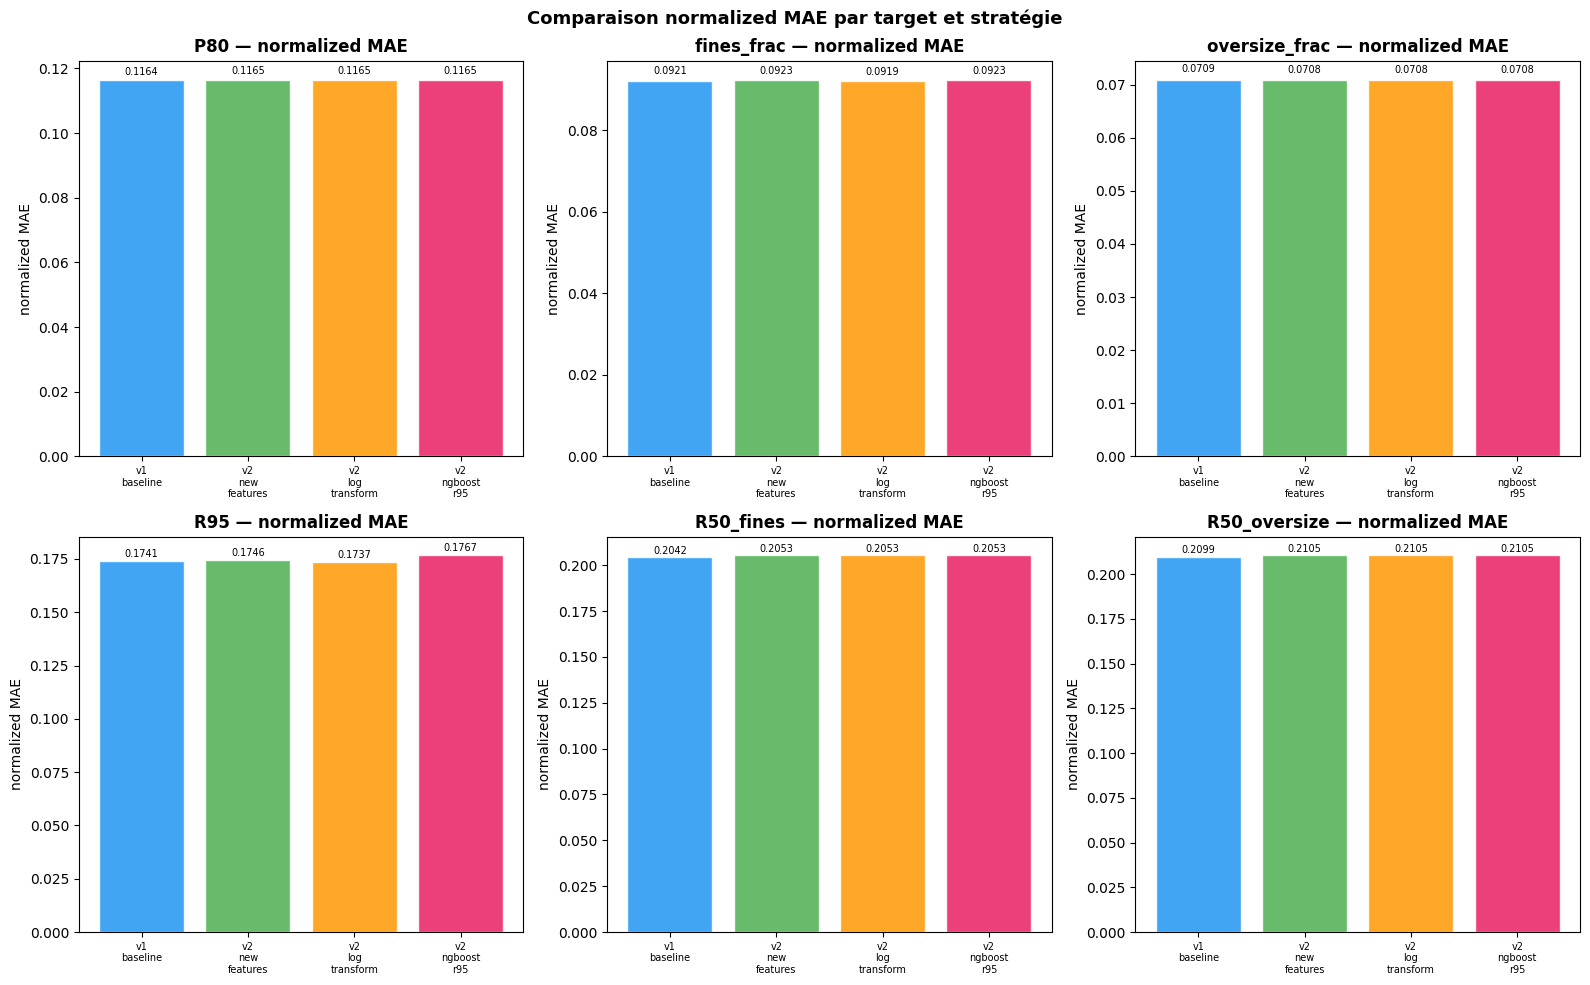

Figure sauvegardée : /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/comparison_normalized_mae.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels_plot = ['v1_baseline', 'v2_new_features', 'v2_log_transform', 'v2_ngboost_r95']

for ax, target in zip(axes, target_cols):
    target_metrics = metrics_df[metrics_df['target'] == target][['strategy', 'MAE', 'normalized_MAE']]
    strats  = target_metrics['strategy'].tolist()
    maes    = target_metrics['normalized_MAE'].tolist()
    cols    = [colors[labels_plot.index(s)] if s in labels_plot else 'gray' for s in strats]
    bars    = ax.bar(range(len(strats)), maes, color=cols, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(strats)))
    ax.set_xticklabels([s.replace('_', '\n') for s in strats], fontsize=7)
    ax.set_title(f'{target} — normalized MAE', fontweight='bold')
    ax.set_ylabel('normalized MAE')
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparaison normalized MAE par target et stratégie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison_normalized_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée :', FIGURES_DIR / 'comparison_normalized_mae.png')

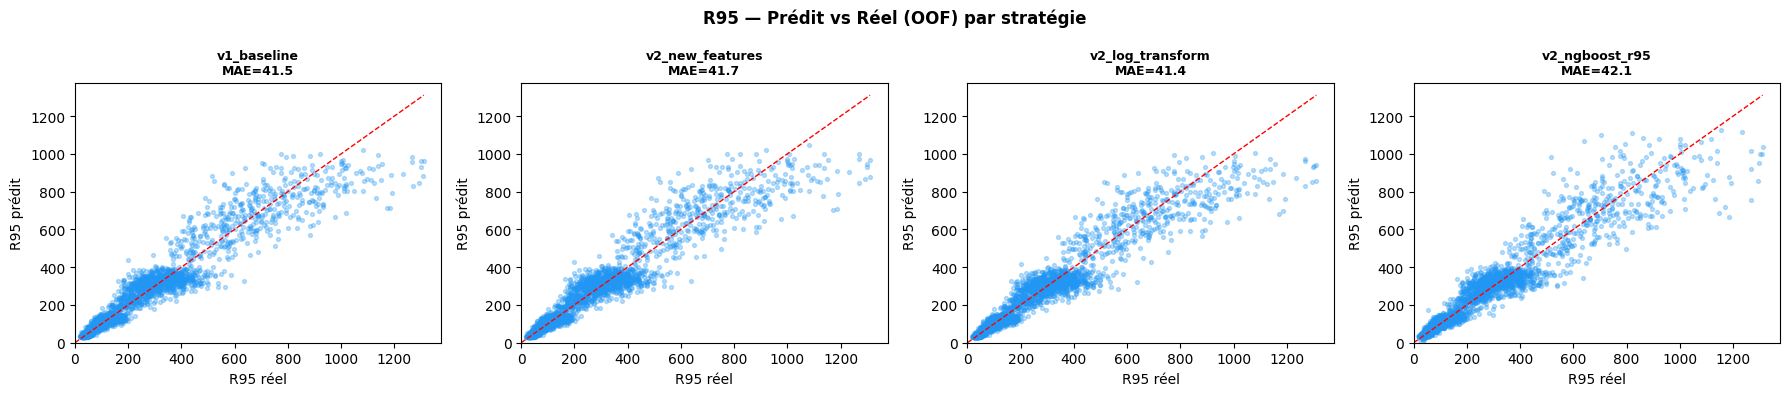

In [17]:
# ── Predicted vs True pour R95 — toutes stratégies ───────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (label, oof) in zip(axes, strategies):
    true = y['R95'].values
    pred = oof['R95'].values
    mae  = mean_absolute_error(true, pred)
    ax.scatter(true, pred, alpha=0.3, s=8, c='#2196F3')
    lim = max(true.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlabel('R95 réel')
    ax.set_ylabel('R95 prédit')
    ax.set_title(f'{label}\nMAE={mae:.1f}', fontsize=9, fontweight='bold')
    ax.set_xlim(0, lim * 1.05)
    ax.set_ylim(0, lim * 1.05)

plt.suptitle('R95 — Prédit vs Réel (OOF) par stratégie', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison_r95_pred_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()

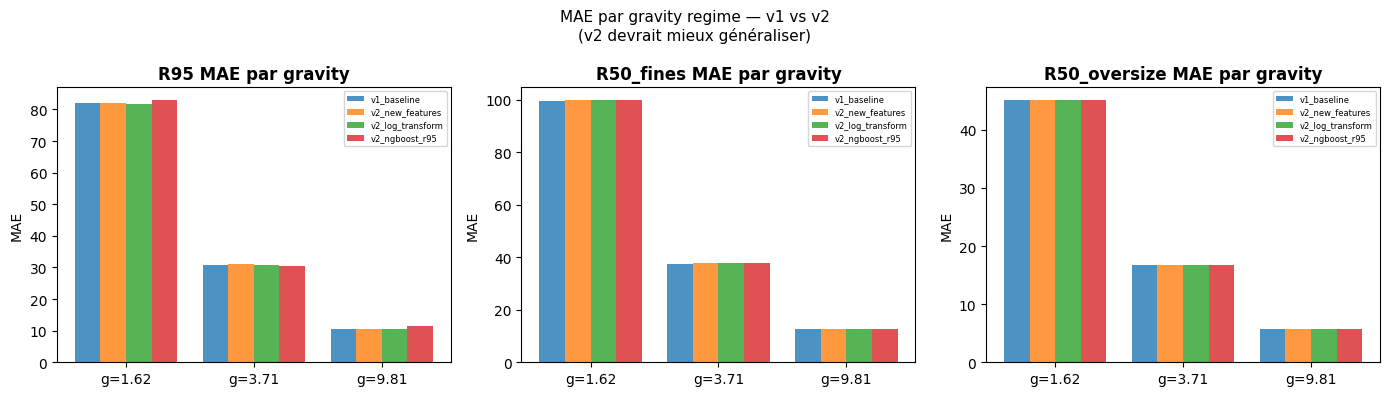

In [18]:
# ── Erreurs par gravity regime ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
gravity_levels = sorted(raw_train['gravity'].unique())
x = np.arange(len(gravity_levels))
width = 0.2

for ax, target in zip(axes, distance_targets):
    for i, (label, oof) in enumerate(strategies):
        maes = []
        for gval in gravity_levels:
            mask = raw_train['gravity'] == gval
            maes.append(mean_absolute_error(y.loc[mask, target], oof.loc[mask, target]))
        ax.bar(x + i * width, maes, width, label=label, alpha=0.8)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'g={g}' for g in gravity_levels])
    ax.set_title(f'{target} MAE par gravity', fontweight='bold')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=6)

plt.suptitle('MAE par gravity regime — v1 vs v2\n(v2 devrait mieux généraliser)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison_gravity_mae.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Entraînement final et prédictions test

In [19]:
CREATE_FINAL_SUBMISSION = False  # Mettre True pour générer la soumission

if CREATE_FINAL_SUBMISSION:
    print(f'Entraînement final avec stratégie : {best_strategy}')

    # Choisir les bons paramètres selon la meilleure stratégie
    fe_func_final     = add_physics_features_v2
    config_final      = target_config_v2
    log_targets_final = ['R95', 'fines_frac'] if 'log' in best_strategy else []
    ngb_r95_final     = 'ngboost' in best_strategy and NGBOOST_AVAILABLE

    X_train_fe = fe_func_final(raw_train)
    X_test_fe  = fe_func_final(raw_test)

    final_models_dict = {}
    test_preds = pd.DataFrame(index=raw_test.index)

    for i, target in enumerate(target_cols):
        feats    = config_final[target]
        X_tr_t   = X_train_fe[feats].values
        X_te_t   = X_test_fe[feats].values
        y_tr_t   = y[target].values

        if ngb_r95_final and target == 'R95':
            model = build_ngboost(random_state=RANDOM_STATE)
            model.fit(X_tr_t, y_tr_t)
        elif target in log_targets_final:
            model = build_extratrees(random_state=RANDOM_STATE + i,
                                     n_estimators=N_ESTIMATORS)
            model.fit(X_tr_t, np.log1p(y_tr_t))
            pred  = np.expm1(model.predict(X_te_t))
        else:
            model = build_extratrees(random_state=RANDOM_STATE + i,
                                     n_estimators=N_ESTIMATORS)
            model.fit(X_tr_t, y_tr_t)

        pred = model.predict(X_te_t) if target not in log_targets_final else pred
        if target not in log_targets_final:
            pred = model.predict(X_te_t)
        test_preds[target]    = clip_predictions(pred, target)
        final_models_dict[target] = model
        print(f'  {target} ✓  pred_mean={test_preds[target].mean():.2f}')

    # Correction biais R95
    if abs(R95_BIAS_CORRECTION) > 1.0:
        test_preds['R95'] = (test_preds['R95'] - R95_BIAS_CORRECTION).clip(lower=0)
        print(f'Correction biais R95 : -{R95_BIAS_CORRECTION:.3f}')

    # Soumission
    submission = pd.DataFrame({'scenario_id': np.arange(len(raw_test))})
    for col in target_cols:
        submission[col] = test_preds[col].values
    submission = submission[['scenario_id'] + target_cols]

    out_path = SUBMISSIONS_DIR / f'prediction_submission_{best_strategy}_v2.csv'
    submission.to_csv(out_path, index=False)
    print(f'\nSoumission sauvegardée : {out_path}')
    display(submission.head())
    display(submission[target_cols].describe().T)

    # Sauvegarder les modèles
    joblib.dump(final_models_dict, MODELS_DIR / f'final_models_{best_strategy}_v2.joblib')

else:
    print('CREATE_FINAL_SUBMISSION = False')
    print(f'Meilleure stratégie identifiée : {best_strategy}')
    print('Mettre CREATE_FINAL_SUBMISSION = True pour générer la soumission.')

CREATE_FINAL_SUBMISSION = False
Meilleure stratégie identifiée : v1_baseline
Mettre CREATE_FINAL_SUBMISSION = True pour générer la soumission.


## 14. Verdict final — quelle soumission choisir

In [20]:
print('=' * 70)
print('VERDICT FINAL — COMPARAISON COMPLÈTE')
print('=' * 70)

for label, oof in strategies:
    m, c = evaluate_oof(oof, label)
    norm_mae_r95 = m[m.target=='R95']['normalized_MAE'].values[0]
    norm_mae_p80 = m[m.target=='P80']['normalized_MAE'].values[0]
    f1           = c['feasible_f1'].values[0]
    bias_r95     = c['near_zone_R95_bias'].values[0] if 'near_zone_R95_bias' in c.columns else float('nan')
    print(f'\n{label}:')
    print(f'  R95  normalized MAE  = {norm_mae_r95:.4f}')
    print(f'  P80  normalized MAE  = {norm_mae_p80:.4f}')
    print(f'  Feasible F1          = {f1:.4f}')
    print(f'  Near-zone R95 bias   = {bias_r95:+.2f}')

print('\n' + '=' * 70)
print(f'→ RECOMMANDATION : utiliser {best_strategy}')
print(f'→ Correction biais R95 à appliquer : -{R95_BIAS_CORRECTION:.3f}')
print('=' * 70)

# Sauvegarder le rapport complet
report = metrics_df.merge(
    constraints_df[['strategy','feasible_f1','near_zone_MAE_R95','near_zone_R95_bias']],
    on='strategy', how='left'
)
report.to_csv(REPORTS_DIR / 'comparison_v1_vs_v2_full_report.csv', index=False)
print(f'\nRapport complet sauvegardé : {REPORTS_DIR}/comparison_v1_vs_v2_full_report.csv')

VERDICT FINAL — COMPARAISON COMPLÈTE

v1_baseline:
  R95  normalized MAE  = 0.1741
  P80  normalized MAE  = 0.1164
  Feasible F1          = 0.3333
  Near-zone R95 bias   = +13.81

v2_new_features:
  R95  normalized MAE  = 0.1746
  P80  normalized MAE  = 0.1165
  Feasible F1          = 0.3333
  Near-zone R95 bias   = +14.16

v2_log_transform:
  R95  normalized MAE  = 0.1737
  P80  normalized MAE  = 0.1165
  Feasible F1          = 0.3333
  Near-zone R95 bias   = +10.39

v2_ngboost_r95:
  R95  normalized MAE  = 0.1767
  P80  normalized MAE  = 0.1165
  Feasible F1          = 0.3333
  Near-zone R95 bias   = +13.68

→ RECOMMANDATION : utiliser v1_baseline
→ Correction biais R95 à appliquer : -13.807

Rapport complet sauvegardé : /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports/comparison_v1_vs_v2_full_report.csv
